## Import Libraries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

## Load Cleaned Datasets

In [2]:

DATA_PATH = "../data/processed"

fund_master = pd.read_csv(f"{DATA_PATH}/01_fund_master_cleaned.csv")

nav = pd.read_csv(f"{DATA_PATH}/02_nav_history_cleaned.csv")

aum = pd.read_csv(f"{DATA_PATH}/03_aum_by_fund_house_cleaned.csv")

sip = pd.read_csv(f"{DATA_PATH}/04_monthly_sip_inflows_cleaned.csv")

category = pd.read_csv(f"{DATA_PATH}/05_category_inflows_cleaned.csv")

folio = pd.read_csv(f"{DATA_PATH}/06_industry_folio_count_cleaned.csv")

performance = pd.read_csv(f"{DATA_PATH}/07_scheme_performance_cleaned.csv")

transactions = pd.read_csv(f"{DATA_PATH}/08_investor_transactions_cleaned.csv")

portfolio = pd.read_csv(f"{DATA_PATH}/09_portfolio_holdings_cleaned.csv")

benchmark = pd.read_csv(f"{DATA_PATH}/10_benchmark_indices_cleaned.csv")

## Convert Date Columns

In [3]:

nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

portfolio["portfolio_date"] = pd.to_datetime(
    portfolio["portfolio_date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

aum["date"] = pd.to_datetime(
    aum["date"]
)

sip["month"] = pd.to_datetime(
    sip["month"]
)

folio["month"] = pd.to_datetime(
    folio["month"]
)

category["month"] = pd.to_datetime(
    category["month"]
)

In [4]:
# ============================================================
# Dataset Shapes
# ============================================================

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Fund Master,40,15
1,NAV History,46000,3
2,AUM,90,5
3,SIP,48,6
4,Category,144,3
5,Folio,21,6
6,Performance,40,19
7,Transactions,32778,13
8,Portfolio,322,8
9,Benchmark,8050,3


## 1. Historical VaR (95%) & CVaR

In [5]:
# ============================================================
# Merge NAV History with Fund Master
# ============================================================

nav_df = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_df.shape)

nav_df.head()

(46000, 4)


,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [6]:
# ============================================================
# Sort Data
# ============================================================

nav_df = nav_df.sort_values(
    by=["scheme_name", "date"]
).reset_index(drop=True)

nav_df.head()

,amfi_code,date,nav,scheme_name
0,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth
1,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth
2,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth
3,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth
4,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth


In [7]:
# ============================================================
# Daily Returns
# ============================================================

nav_df["daily_return"] = (
    nav_df
    .groupby("scheme_name")["nav"]
    .pct_change()
)

nav_df.head()

,amfi_code,date,nav,scheme_name,daily_return
0,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
1,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
2,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
4,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


In [8]:
returns_df = nav_df.dropna(subset=["daily_return"])

print("Total Return Records :", len(returns_df))
print("Total Schemes :", returns_df["scheme_name"].nunique())

Total Return Records : 45960
Total Schemes : 40


In [9]:
# ============================================================
# Historical VaR & CVaR
# ============================================================

risk_metrics = []

for scheme, group in returns_df.groupby("scheme_name"):

    returns = group["daily_return"]

    # Historical VaR (95%)
    var95 = np.percentile(returns, 5)

    # Conditional VaR
    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "Scheme Name": scheme,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar = pd.DataFrame(risk_metrics)

var_cvar.head()

,Scheme Name,VaR_95,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


In [10]:
var_cvar["VaR (%)"] = (
    var_cvar["VaR_95"] * 100
).round(2)

var_cvar["CVaR (%)"] = (
    var_cvar["CVaR_95"] * 100
).round(2)

var_cvar.head()

,Scheme Name,VaR_95,CVaR_95,VaR (%),CVaR (%)
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439,-1.33,-1.74
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422,-0.03,-0.04
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459,-2.60,-3.25
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487,-1.42,-1.75
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328,-1.37,-1.73


In [11]:
# ============================================================
# Rank Funds
# ============================================================

var_cvar = (
    var_cvar
    .sort_values("VaR_95")
    .reset_index(drop=True)
)

var_cvar

,Scheme Name,VaR_95,CVaR_95,VaR (%),CVaR (%)
0,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384,-2.69,-3.24
1,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667,-2.62,-3.17
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459,-2.60,-3.25
3,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304,-2.54,-3.23
4,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595,-2.45,-3.06
...,...,...,...,...,...
35,Nippon India Gilt Securities Fund - Regular - ...,-0.003804,-0.004919,-0.38,-0.49
36,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994,-0.38,-0.50
37,Kotak Liquid Fund - Regular - Growth,-0.000285,-0.000411,-0.03,-0.04
38,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422,-0.03,-0.04


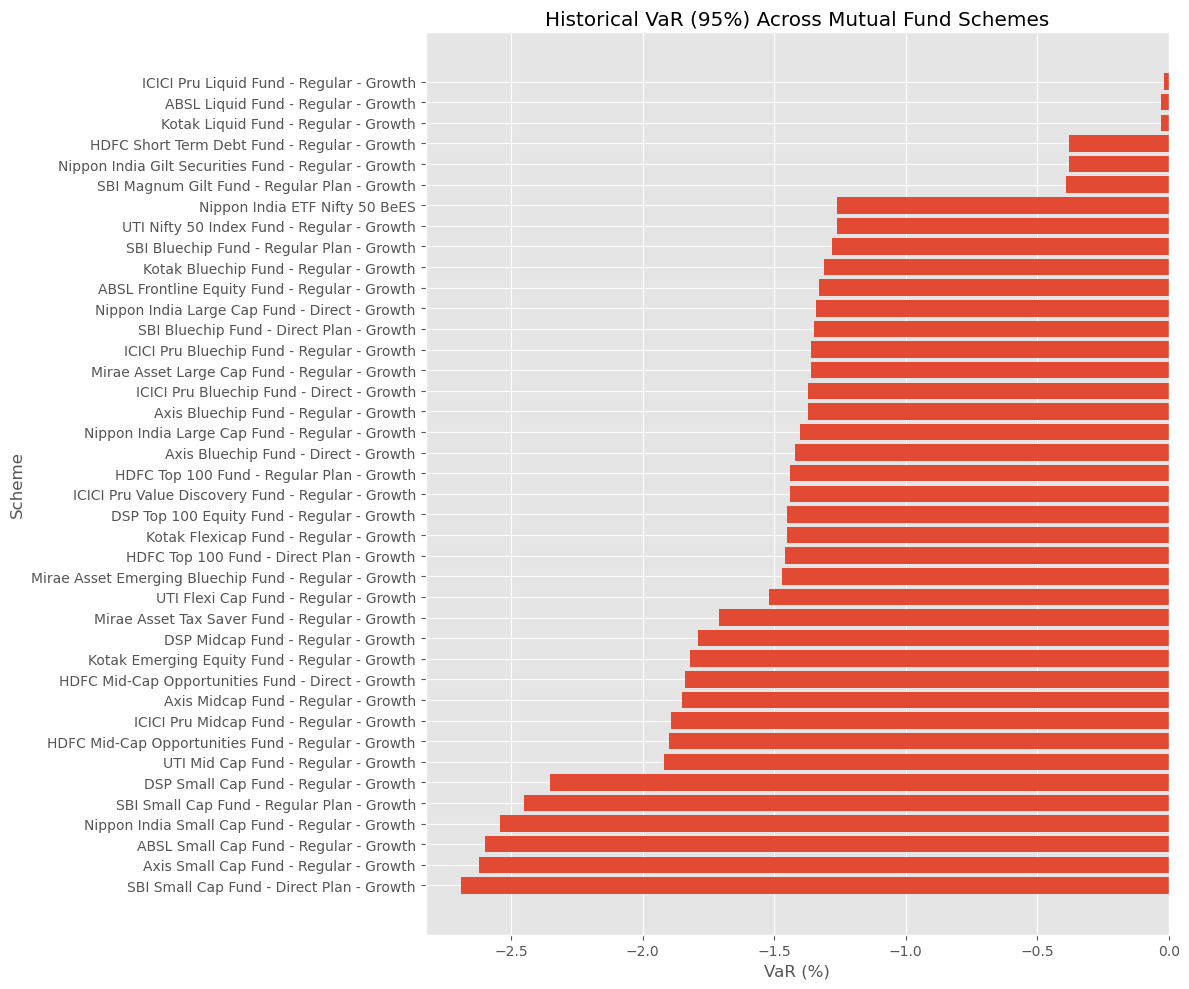

In [12]:
# ============================================================
# Visualization
# ============================================================


plt.figure(figsize=(12,10))

plt.barh(
    var_cvar["Scheme Name"],
    var_cvar["VaR (%)"]
)

plt.title("Historical VaR (95%) Across Mutual Fund Schemes")

plt.xlabel("VaR (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

In [13]:
# ============================================================
# Export Report
# ============================================================

var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("✅ var_cvar_report.csv saved successfully.")

✅ var_cvar_report.csv saved successfully.


In [14]:
# ============================================================
# Display Top & Bottom Funds
# ============================================================



print("="*70)
print("Top 5 Highest Downside Risk Funds")
print("="*70)

display(
    var_cvar[
        ["Scheme Name", "VaR (%)", "CVaR (%)"]
    ].head()
)

print("="*70)
print("Top 5 Lowest Downside Risk Funds")
print("="*70)

display(
    var_cvar[
        ["Scheme Name", "VaR (%)", "CVaR (%)"]
    ].tail()
)

Top 5 Highest Downside Risk Funds


,Scheme Name,VaR (%),CVaR (%)
0,SBI Small Cap Fund - Direct Plan - Growth,-2.69,-3.24
1,Axis Small Cap Fund - Regular - Growth,-2.62,-3.17
2,ABSL Small Cap Fund - Regular - Growth,-2.60,-3.25
3,Nippon India Small Cap Fund - Regular - Growth,-2.54,-3.23
4,SBI Small Cap Fund - Regular Plan - Growth,-2.45,-3.06


Top 5 Lowest Downside Risk Funds


,Scheme Name,VaR (%),CVaR (%)
35,Nippon India Gilt Securities Fund - Regular - ...,-0.38,-0.49
36,HDFC Short Term Debt Fund - Regular - Growth,-0.38,-0.50
37,Kotak Liquid Fund - Regular - Growth,-0.03,-0.04
38,ABSL Liquid Fund - Regular - Growth,-0.03,-0.04
39,ICICI Pru Liquid Fund - Regular - Growth,-0.02,-0.04


#### Insight:

##### - Historical VaR (95%) estimates the worst expected daily loss under normal market conditions with 95% confidence.
##### - Funds with more negative VaR values exhibit higher downside volatility.
##### - CVaR measures the average loss during the worst 5% of trading days and therefore captures tail risk more effectively than VaR.
##### - Comparing VaR and CVaR across all 40 schemes helps identify funds that are relatively more resilient versus those exposed to greater downside risk.
##### - These metrics support investors in evaluating downside risk before selecting mutual fund schemes.

## 2. Rolling 90-day Sharpe

In [15]:
# ============================================================
# Prepare Data
# ============================================================

rolling_df = nav_df.copy()

rolling_df = rolling_df.dropna(subset=["daily_return"])

rolling_df.head()

,amfi_code,date,nav,scheme_name,daily_return
1,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
2,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
4,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314
5,101206,2022-01-10,307.5591,ABSL Frontline Equity Fund - Regular - Growth,0.011548


In [16]:
# ============================================================
# Rolling 90-Day Sharpe Ratio
# ============================================================

rolling_df["rolling_sharpe"] = (

    rolling_df
    .groupby("scheme_name")["daily_return"]

    .transform(

        lambda x:

        (
            x.rolling(90).mean()

            /

            x.rolling(90).std()

        ) * np.sqrt(252)

    )

)

rolling_df.head()

,amfi_code,date,nav,scheme_name,daily_return,rolling_sharpe
1,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153,NaN
2,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866,NaN
3,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128,NaN
4,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314,NaN
5,101206,2022-01-10,307.5591,ABSL Frontline Equity Fund - Regular - Growth,0.011548,NaN


In [17]:
rolling_df[
    [
        "scheme_name",
        "date",
        "daily_return",
        "rolling_sharpe"
    ]
].head(15)

,scheme_name,date,daily_return,rolling_sharpe
1,ABSL Frontline Equity Fund - Regular - Growth,2022-01-04,0.001153,NaN
2,ABSL Frontline Equity Fund - Regular - Growth,2022-01-05,0.003866,NaN
3,ABSL Frontline Equity Fund - Regular - Growth,2022-01-06,-0.002128,NaN
4,ABSL Frontline Equity Fund - Regular - Growth,2022-01-07,-0.006314,NaN
5,ABSL Frontline Equity Fund - Regular - Growth,2022-01-10,0.011548,NaN
6,ABSL Frontline Equity Fund - Regular - Growth,2022-01-11,0.006106,NaN
7,ABSL Frontline Equity Fund - Regular - Growth,2022-01-12,0.012167,NaN
8,ABSL Frontline Equity Fund - Regular - Growth,2022-01-13,-0.007863,NaN
9,ABSL Frontline Equity Fund - Regular - Growth,2022-01-14,-0.005714,NaN
10,ABSL Frontline Equity Fund - Regular - Growth,2022-01-17,0.011189,NaN


In [18]:
# ============================================================
# Select Five Key Funds
# ============================================================

key_funds = [

    "SBI Bluechip Fund - Regular Plan - Growth",

    "HDFC Top 100 Fund - Regular Plan - Growth",

    "ICICI Pru Bluechip Fund - Regular - Growth",

    "Axis Bluechip Fund - Regular - Growth",

    "Nippon India Large Cap Fund - Regular - Growth"

]

key_funds

['SBI Bluechip Fund - Regular Plan - Growth',
 'HDFC Top 100 Fund - Regular Plan - Growth',
 'ICICI Pru Bluechip Fund - Regular - Growth',
 'Axis Bluechip Fund - Regular - Growth',
 'Nippon India Large Cap Fund - Regular - Growth']

In [19]:
# ============================================================
# Filter Data
# ============================================================

rolling_plot = rolling_df[
    rolling_df["scheme_name"].isin(key_funds)
].copy()

rolling_plot.head()

,amfi_code,date,nav,scheme_name,daily_return,rolling_sharpe
4601,119092,2022-01-04,38.4924,Axis Bluechip Fund - Regular - Growth,-0.006561,NaN
4602,119092,2022-01-05,38.2033,Axis Bluechip Fund - Regular - Growth,-0.007511,NaN
4603,119092,2022-01-06,38.5825,Axis Bluechip Fund - Regular - Growth,0.009926,NaN
4604,119092,2022-01-07,38.9425,Axis Bluechip Fund - Regular - Growth,0.009331,NaN
4605,119092,2022-01-10,38.5546,Axis Bluechip Fund - Regular - Growth,-0.009961,NaN


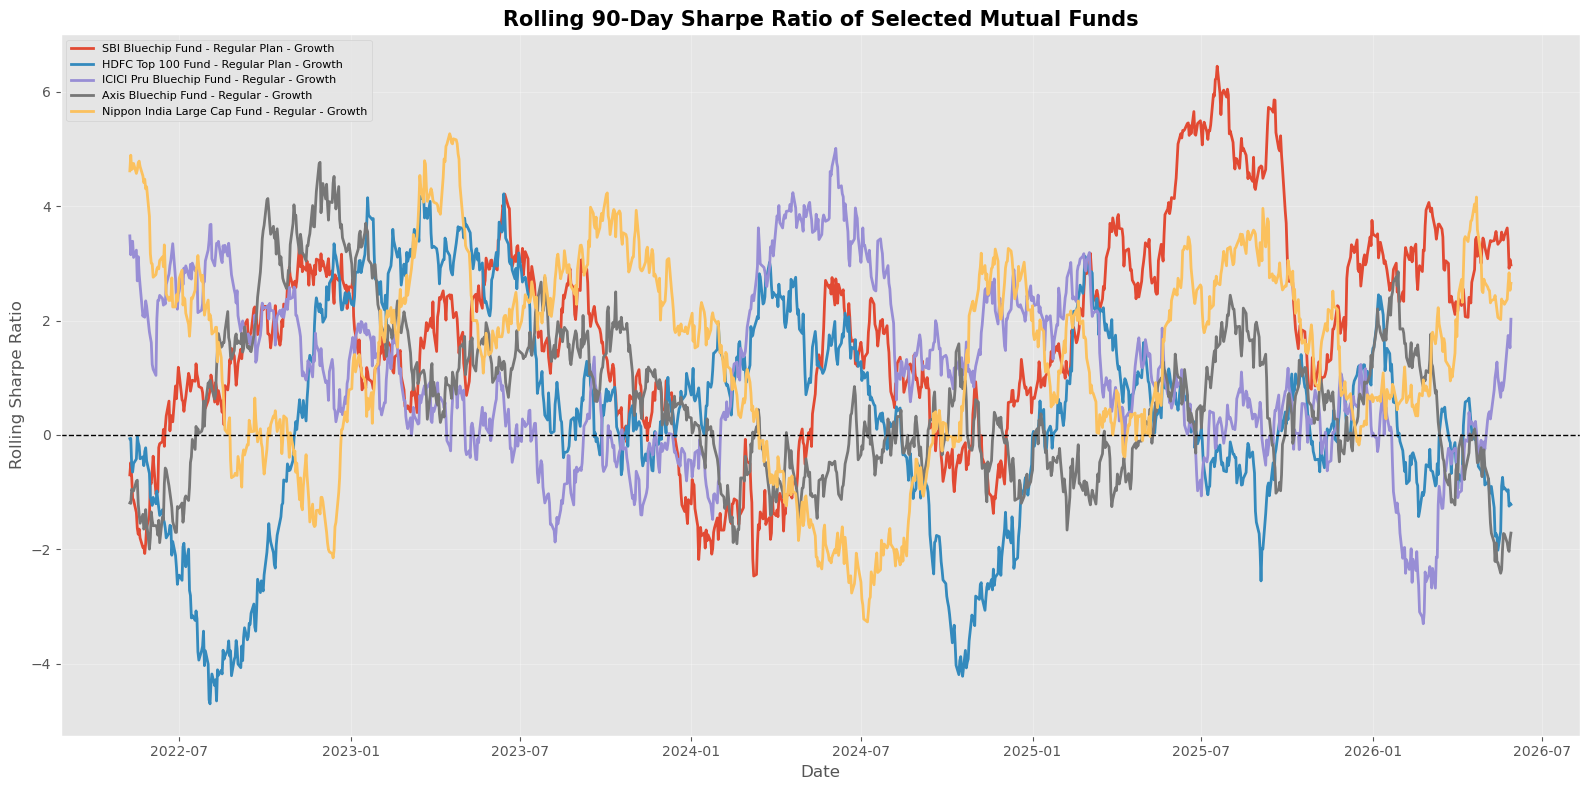

In [20]:
# ============================================================
# Plot Rolling Sharpe Ratio & Save Figure
# ============================================================

plt.figure(figsize=(16,8))

for fund in key_funds:

    temp = rolling_plot[
        rolling_plot["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        linewidth=2,
        label=fund
    )

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Rolling 90-Day Sharpe Ratio of Selected Mutual Funds",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("Rolling Sharpe Ratio")

plt.legend(fontsize=8)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ============================================================
# Rolling Sharpe Summary
# ============================================================

rolling_summary = (

    rolling_plot

    .groupby("scheme_name")["rolling_sharpe"]

    .agg(

        Average="mean",

        Maximum="max",

        Minimum="min",

        Latest="last"

    )

    .round(2)

)

rolling_summary

,Average,Maximum,Minimum,Latest
scheme_name,,,,
Axis Bluechip Fund - Regular - Growth,0.62,4.77,-2.42,-1.72
HDFC Top 100 Fund - Regular Plan - Growth,0.34,4.21,-4.70,-1.22
ICICI Pru Bluechip Fund - Regular - Growth,1.04,5.01,-3.30,2.02
Nippon India Large Cap Fund - Regular - Growth,1.40,5.27,-3.27,2.65
SBI Bluechip Fund - Regular Plan - Growth,1.73,6.45,-2.47,2.97


In [22]:
# ============================================================
# Export Rolling Sharpe Summary
# ============================================================

rolling_summary.to_csv(
    "../reports/rolling_sharpe_summary.csv"
)

print("✅ rolling_sharpe_summary.csv saved successfully.")

✅ rolling_sharpe_summary.csv saved successfully.


#### Insight

##### - The Rolling 90-Day Sharpe Ratio provides a dynamic view of risk-adjusted performance rather than a single overall value.

##### - Positive Sharpe Ratios indicate that the mutual fund generated returns higher than its associated volatility during that period.

##### - Negative Sharpe Ratios indicate periods where the fund underperformed relative to the level of risk taken.

##### - Bluechip and large-cap funds generally exhibit more stable Sharpe Ratios compared to mid-cap and small-cap funds because of lower market volatility.

##### - Investors can monitor rolling Sharpe trends to identify periods of improving or deteriorating fund performance and make better investment decisions.

## 3. Investor cohort analysis

In [23]:
# ============================================================
# Prepare Transaction Data
# ============================================================

cohort_df = transactions.copy()

cohort_df["transaction_date"] = pd.to_datetime(
    cohort_df["transaction_date"]
)

cohort_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [24]:
# ============================================================
# Merge Scheme Name
# ============================================================

cohort_df = cohort_df.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",
    how="left"

)

cohort_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,Axis Midcap Fund - Regular - Growth


In [25]:
# ============================================================
# First Transaction Year
# ============================================================

first_transaction = (

    cohort_df
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction.rename(
    columns={
        "transaction_date":"first_transaction"
    },
    inplace=True
)

first_transaction["cohort_year"] = (
    first_transaction["first_transaction"]
    .dt.year
)

first_transaction.head()

,investor_id,first_transaction,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [26]:
# ============================================================
# Assign Cohort Year
# ============================================================

cohort_df = cohort_df.merge(

    first_transaction[
        ["investor_id","cohort_year"]
    ],

    on="investor_id",
    how="left"

)

cohort_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Axis Bluechip Fund - Regular - Growth,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,Mirae Asset Large Cap Fund - Regular - Growth,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,Nippon India Gilt Securities Fund - Regular - ...,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,Nippon India Small Cap Fund - Regular - Growth,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,Axis Midcap Fund - Regular - Growth,2024


In [27]:
# ============================================================
# Average SIP Amount
# ============================================================

avg_sip = (
    cohort_df[
        cohort_df["transaction_type"]=="SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .round(2)
    .reset_index()
)

avg_sip.rename(
    columns={
        "amount_inr":"Average SIP Amount"
    },
    inplace=True
)

avg_sip

,cohort_year,Average SIP Amount
0,2024,10996.89
1,2025,13505.21


In [28]:
# ============================================================
# Total Investment
# ============================================================

investments = cohort_df[
    cohort_df["transaction_type"]!="Redemption"
]

total_investment = (
    investments
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
)

total_investment.rename(
    columns={
        "amount_inr":"Total Investment"
    },
    inplace=True
)

total_investment

,cohort_year,Total Investment
0,2024,2258062304
1,2025,18992635


In [29]:
# ============================================================
# Most Preferred Fund
# ============================================================

top_fund = (
    investments
    .groupby(
        [
            "cohort_year",
            "scheme_name"
        ]
    )
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        [
            "cohort_year",
            "count"
        ],
        ascending=[True,False]
    )
    .drop_duplicates(
        subset="cohort_year"
    )
)

top_fund = top_fund[
    [
        "cohort_year",
        "scheme_name"
    ]
]

top_fund.rename(
    columns={
        "scheme_name":"Top Fund Preference"
    },
    inplace=True

)

top_fund

,cohort_year,Top Fund Preference
10,2024,HDFC Mid-Cap Opportunities Fund - Direct - Growth
75,2025,SBI Small Cap Fund - Direct Plan - Growth


In [30]:
# ============================================================
# Final Cohort Analysis
# ============================================================

cohort_summary = (

    avg_sip

    .merge(

        total_investment,

        on="cohort_year"

    )

    .merge(

        top_fund,

        on="cohort_year"

    )

)

cohort_summary

,cohort_year,Average SIP Amount,Total Investment,Top Fund Preference
0,2024,10996.89,2258062304,HDFC Mid-Cap Opportunities Fund - Direct - Growth
1,2025,13505.21,18992635,SBI Small Cap Fund - Direct Plan - Growth


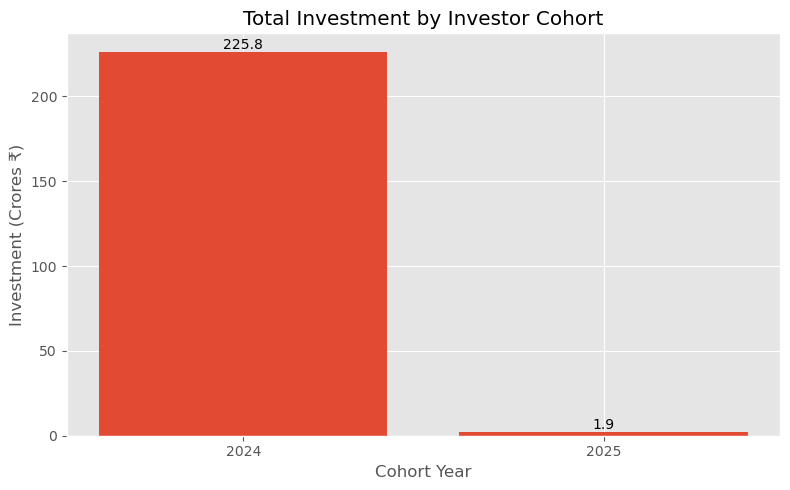

In [31]:
# ============================================================
# Total Investment by Investor Cohort
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    cohort_summary["cohort_year"].astype(str),
    cohort_summary["Total Investment"]/1e7
)

plt.title("Total Investment by Investor Cohort")

plt.xlabel("Cohort Year")

plt.ylabel("Investment (Crores ₹)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.show()

In [32]:
# ============================================================
# Export Report
# ============================================================

cohort_summary.to_csv(

    "../reports/cohort_analysis.csv",

    index=False

)

print("✅ cohort_analysis.csv saved successfully.")

✅ cohort_analysis.csv saved successfully.


#### Insight

##### - Investors were grouped based on the year of their first investment transaction.

##### - The analysis highlights the average SIP contribution and cumulative investment made by each investor cohort.

##### - The most preferred mutual fund for each cohort was identified using transaction frequency.

##### - Since the provided dataset begins in 2024, investor cohorts are expected to be concentrated within the available transaction period.

##### - Cohort analysis enables fund managers to understand investment behaviour and identify trends across different generations of investors.

## 4. SIP continuity analysis

In [33]:
# ============================================================
# Prepare SIP Transactions
# ============================================================

sip_df = transactions.copy()

sip_df["transaction_date"] = pd.to_datetime(
    sip_df["transaction_date"]
)

# Keep only SIP transactions
sip_df = sip_df[
    sip_df["transaction_type"] == "SIP"
].copy()

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [34]:
# ============================================================
# Investors Having 6 or More SIP Transactions
# ============================================================

sip_counts = (
    sip_df
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

sip_df = sip_df[
    sip_df["investor_id"].isin(eligible_investors)
].copy()

print("Eligible Investors :", sip_df["investor_id"].nunique())

Eligible Investors : 1362


In [35]:
# ============================================================
# Sort Transactions
# ============================================================

sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified


In [36]:
# ============================================================
# Calculate Gap Between Consecutive SIPs
# ============================================================

sip_df["gap_days"] = (

    sip_df

    .groupby("investor_id")["transaction_date"]

    .diff()

    .dt.days

)

sip_df.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,265.0
31897,INV000004,2025-05-17,119599,SIP,2110,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,49.0
9329,INV000008,2024-05-27,101206,SIP,8061,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,NaN
11113,INV000008,2024-06-23,102887,SIP,55850,Punjab,Amritsar,B30,26-35,Female,18.6,Net Banking,Verified,27.0
21549,INV000008,2024-12-05,100025,SIP,425,Punjab,Amritsar,B30,26-35,Female,18.6,UPI,Verified,165.0
24389,INV000008,2025-01-18,119552,SIP,458,Punjab,Amritsar,B30,26-35,Female,18.6,Cheque,Verified,44.0


In [37]:
# ============================================================
# Average Gap
# ============================================================

avg_gap = (

    sip_df

    .groupby("investor_id")["gap_days"]

    .mean()

    .round(2)

    .reset_index()

)

avg_gap.rename(

    columns={

        "gap_days":"Average Gap (Days)"

    },

    inplace=True

)

avg_gap.head()

,investor_id,Average Gap (Days)
0,INV000004,85.40
1,INV000008,70.40
2,INV000010,64.80
3,INV000011,40.17
4,INV000012,57.00


In [38]:
# ============================================================
# Risk Classification
# ============================================================

avg_gap["Risk Status"] = np.where(

    avg_gap["Average Gap (Days)"] > 35,

    "At Risk",

    "Regular"

)

avg_gap.head()

,investor_id,Average Gap (Days),Risk Status
0,INV000004,85.40,At Risk
1,INV000008,70.40,At Risk
2,INV000010,64.80,At Risk
3,INV000011,40.17,At Risk
4,INV000012,57.00,At Risk


In [39]:
# ============================================================
# Merge SIP Count
# ============================================================

avg_gap = avg_gap.merge(

    sip_counts,

    on="investor_id",

    how="left"

)

avg_gap.head()

,investor_id,Average Gap (Days),Risk Status,sip_count
0,INV000004,85.40,At Risk,6
1,INV000008,70.40,At Risk,6
2,INV000010,64.80,At Risk,6
3,INV000011,40.17,At Risk,7
4,INV000012,57.00,At Risk,8


In [40]:
# ============================================================
# Summary Statistics
# ============================================================

summary = (

    avg_gap["Risk Status"]

    .value_counts()

    .reset_index()

)

summary.columns = [

    "Risk Status",

    "Investor Count"

]

summary

,Risk Status,Investor Count
0,At Risk,1332
1,Regular,30


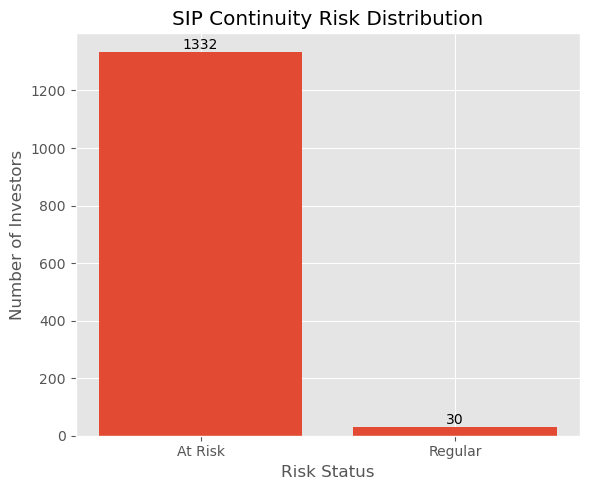

In [41]:
# ============================================================
# Risk Distribution
# ============================================================

plt.figure(figsize=(6,5))

bars = plt.bar(

    summary["Risk Status"],

    summary["Investor Count"]

)

plt.title("SIP Continuity Risk Distribution")

plt.xlabel("Risk Status")

plt.ylabel("Number of Investors")

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height,

        f"{int(height)}",

        ha="center",

        va="bottom"

    )

plt.tight_layout()

plt.show()

In [42]:
# ============================================================
# Top At Risk Investors
# ============================================================

at_risk = (

    avg_gap

    .query("`Risk Status`=='At Risk'")

    .sort_values(

        "Average Gap (Days)",

        ascending=False

    )

)

at_risk.head(10)

,investor_id,Average Gap (Days),Risk Status,sip_count
506,INV001890,102.6,At Risk,6
323,INV001156,102.4,At Risk,6
1188,INV004296,102.2,At Risk,6
910,INV003325,101.0,At Risk,6
150,INV000522,100.8,At Risk,6
183,INV000608,100.2,At Risk,6
503,INV001883,99.2,At Risk,6
576,INV002166,99.2,At Risk,6
380,INV001367,99.0,At Risk,6
406,INV001491,98.8,At Risk,6


In [43]:
sip_dates = (

    sip_df

    .groupby("investor_id")["transaction_date"]

    .agg(

        First_SIP="min",

        Last_SIP="max"

    )

    .reset_index()

)

avg_gap = avg_gap.merge(

    sip_dates,

    on="investor_id",

    how="left"

)

avg_gap.head()

,investor_id,Average Gap (Days),Risk Status,sip_count,First_SIP,Last_SIP
0,INV000004,85.40,At Risk,6,2024-03-16,2025-05-17
1,INV000008,70.40,At Risk,6,2024-05-27,2025-05-14
2,INV000010,64.80,At Risk,6,2024-04-11,2025-03-01
3,INV000011,40.17,At Risk,7,2024-01-03,2024-08-31
4,INV000012,57.00,At Risk,8,2024-03-27,2025-04-30


In [44]:
# ============================================================
# Export Report
# ============================================================

avg_gap.to_csv(

    "../reports/sip_continuity.csv",

    index=False

)

print("✅ sip_continuity.csv saved successfully.")

✅ sip_continuity.csv saved successfully.


#### Insight

##### - Investors with at least six SIP transactions were analysed to evaluate investment continuity.

##### - The average interval between consecutive SIP investments was calculated for every eligible investor.

##### - A majority of investors (1,332) exhibited an average SIP interval greater than 35 days and were classified as **At Risk**, indicating irregular investment behaviour.

##### - Only 30 investors maintained an average SIP interval within the expected monthly investment cycle and were classified as **Regular**.

##### - SIP continuity analysis enables mutual fund companies to identify investors with declining investment discipline and supports proactive retention strategies.

## 5. Simple fund recommender 


##### A rule-based recommendation system was developed to recommend mutual funds based on investor risk appetite.

##### The recommendation engine filters mutual funds according to the selected risk grade and ranks them using the Sharpe Ratio.

##### The implementation is provided separately in: scripts/recommender.py

#### Inputs

##### - Low Risk
##### - Moderate Risk
##### - High Risk

#### Output

##### - Top 3 Recommended Mutual Funds
##### - Risk Grade
##### - Sharpe Ratio
##### - Expense Ratio
##### - 3-Year Return



In [45]:
print("Recommendation System implemented successfully.")
print("Run scripts/recommender.py to generate personalized fund recommendations.")

Recommendation System implemented successfully.
Run scripts/recommender.py to generate personalized fund recommendations.


#### Insight

##### - A simple rule-based recommendation system was developed using the calculated Sharpe Ratio and the provided risk grade information.

##### - Based on the selected investor risk appetite (Low, Moderate, or High), the system filters the eligible mutual funds and recommends the top three funds with the highest Sharpe Ratio.

##### - This demonstrates how historical performance metrics can be integrated into a basic decision-support system for mutual fund selection.

## 5. Sector HHI concentration 

In [46]:
# ============================================================
# Prepare Portfolio Data
# ============================================================

hhi_df = portfolio.copy()

hhi_df["weight"] = hhi_df["weight_pct"] / 100

hhi_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [47]:
# ============================================================
# Merge Fund Details
# ============================================================

hhi_df = hhi_df.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],

    on="amfi_code",

    how="left"

)

hhi_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight,scheme_name,category
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385,SBI Bluechip Fund - Regular Plan - Growth,Equity
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119,SBI Bluechip Fund - Regular Plan - Growth,Equity
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990,SBI Bluechip Fund - Regular Plan - Growth,Equity
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476,SBI Bluechip Fund - Regular Plan - Growth,Equity
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025,SBI Bluechip Fund - Regular Plan - Growth,Equity


In [48]:
# ============================================================
# Filter Equity Funds
# ============================================================

equity_df = hhi_df[
    hhi_df["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
].copy()

print("Equity Funds :", equity_df["scheme_name"].nunique())

Equity Funds : 34


In [49]:
# ============================================================
# Sector Allocation
# ============================================================

sector_weights = (

    equity_df

    .groupby(
        [
            "scheme_name",
            "sector"
        ]
    )["weight"]

    .sum()

    .reset_index()

)

sector_weights.head()

,scheme_name,sector,weight
0,ABSL Frontline Equity Fund - Regular - Growth,Automobile,0.2501
1,ABSL Frontline Equity Fund - Regular - Growth,Banking,0.2509
2,ABSL Frontline Equity Fund - Regular - Growth,Energy,0.1011
3,ABSL Frontline Equity Fund - Regular - Growth,Infrastructure,0.1491
4,ABSL Frontline Equity Fund - Regular - Growth,Pharma,0.0979


In [50]:
# ============================================================
# Calculate HHI
# ============================================================

sector_hhi = (

    sector_weights

    .groupby("scheme_name")["weight"]

    .apply(lambda x: (x**2).sum())

    .reset_index()

)

sector_hhi.columns = [

    "Scheme Name",

    "HHI"

]

sector_hhi.head()

,Scheme Name,HHI
0,ABSL Frontline Equity Fund - Regular - Growth,0.180042
1,ABSL Small Cap Fund - Regular - Growth,0.222727
2,Axis Bluechip Fund - Direct - Growth,0.184233
3,Axis Bluechip Fund - Regular - Growth,0.296769
4,Axis Midcap Fund - Regular - Growth,0.175100


In [51]:
# ============================================================
# Concentration Level
# ============================================================

def classify_hhi(hhi):

    if hhi < 0.15:
        return "Highly Diversified"

    elif hhi < 0.25:
        return "Moderately Concentrated"

    else:
        return "Highly Concentrated"

sector_hhi["Concentration"] = (

    sector_hhi["HHI"]

    .apply(classify_hhi)

)

sector_hhi.head()

,Scheme Name,HHI,Concentration
0,ABSL Frontline Equity Fund - Regular - Growth,0.180042,Moderately Concentrated
1,ABSL Small Cap Fund - Regular - Growth,0.222727,Moderately Concentrated
2,Axis Bluechip Fund - Direct - Growth,0.184233,Moderately Concentrated
3,Axis Bluechip Fund - Regular - Growth,0.296769,Highly Concentrated
4,Axis Midcap Fund - Regular - Growth,0.175100,Moderately Concentrated


In [52]:
# ============================================================
# Rank Funds by HHI
# ============================================================

sector_hhi = (
    sector_hhi
    .sort_values("HHI", ascending=False)
    .reset_index(drop=True)
)

# Round HHI values for better readability
sector_hhi["HHI"] = sector_hhi["HHI"].round(3)

sector_hhi

,Scheme Name,HHI,Concentration
0,Axis Bluechip Fund - Regular - Growth,0.297,Highly Concentrated
1,Mirae Asset Tax Saver Fund - Regular - Growth,0.255,Highly Concentrated
2,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253,Highly Concentrated
3,UTI Flexi Cap Fund - Regular - Growth,0.251,Highly Concentrated
4,DSP Midcap Fund - Regular - Growth,0.241,Moderately Concentrated
...,...,...,...
29,Nippon India Small Cap Fund - Regular - Growth,0.160,Moderately Concentrated
30,Axis Small Cap Fund - Regular - Growth,0.160,Moderately Concentrated
31,SBI Bluechip Fund - Regular Plan - Growth,0.142,Highly Diversified
32,Kotak Flexicap Fund - Regular - Growth,0.136,Highly Diversified


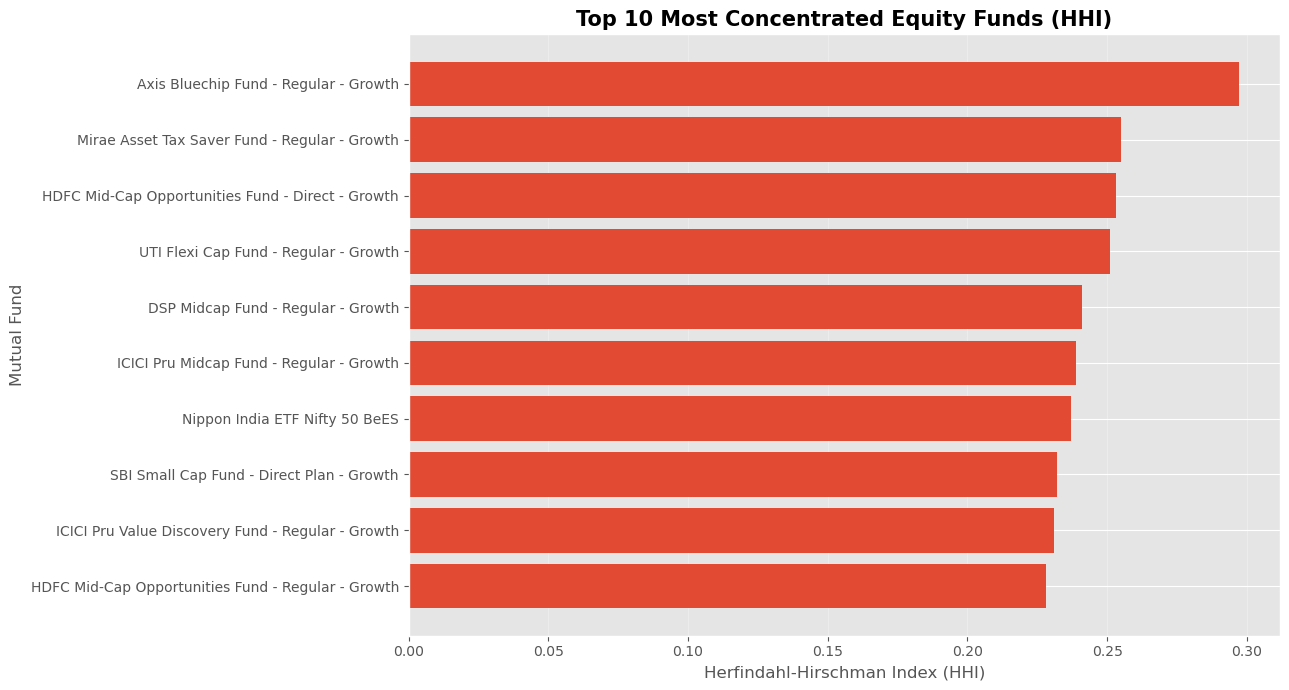

In [53]:
# ============================================================
# Top 10 Most Concentrated Equity Funds
# ============================================================

top10 = sector_hhi.head(10)

plt.figure(figsize=(13,7))

plt.barh(
    top10["Scheme Name"],
    top10["HHI"]
)

plt.title(
    "Top 10 Most Concentrated Equity Funds (HHI)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Herfindahl-Hirschman Index (HHI)")
plt.ylabel("Mutual Fund")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_hhi_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
# ============================================================
# Export HHI Report
# ============================================================

sector_hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

print("✅ sector_hhi.csv saved successfully.")
print("✅ sector_hhi_concentration.png saved successfully.")

✅ sector_hhi.csv saved successfully.
✅ sector_hhi_concentration.png saved successfully.


In [55]:
# ============================================================
# Display HHI Summary
# ============================================================

print("=" * 75)
print("Top 5 Most Concentrated Equity Funds")
print("=" * 75)

display(sector_hhi.head())

print("\n")

print("=" * 75)
print("Top 5 Most Diversified Equity Funds")
print("=" * 75)

display(sector_hhi.tail())

Top 5 Most Concentrated Equity Funds


,Scheme Name,HHI,Concentration
0,Axis Bluechip Fund - Regular - Growth,0.297,Highly Concentrated
1,Mirae Asset Tax Saver Fund - Regular - Growth,0.255,Highly Concentrated
2,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253,Highly Concentrated
3,UTI Flexi Cap Fund - Regular - Growth,0.251,Highly Concentrated
4,DSP Midcap Fund - Regular - Growth,0.241,Moderately Concentrated




Top 5 Most Diversified Equity Funds


,Scheme Name,HHI,Concentration
29,Nippon India Small Cap Fund - Regular - Growth,0.160,Moderately Concentrated
30,Axis Small Cap Fund - Regular - Growth,0.160,Moderately Concentrated
31,SBI Bluechip Fund - Regular Plan - Growth,0.142,Highly Diversified
32,Kotak Flexicap Fund - Regular - Growth,0.136,Highly Diversified
33,UTI Mid Cap Fund - Regular - Growth,0.124,Highly Diversified


#### Insight

##### - The Herfindahl-Hirschman Index (HHI) was computed by aggregating sector allocation weights for each equity mutual fund and summing the squared sector weights.

##### - **Axis Bluechip Fund - Regular - Growth** recorded the highest HHI (0.297), indicating the highest sector concentration among the analyzed equity funds.

##### - **UTI Mid Cap Fund - Regular - Growth** achieved the lowest HHI (0.124), reflecting the most diversified sector allocation.

##### - Highly concentrated funds may outperform during favorable sector cycles but are exposed to greater sector-specific risk, whereas diversified funds generally offer better risk distribution.

##### - HHI serves as a complementary risk metric alongside VaR, Sharpe Ratio, and Drawdown, helping investors evaluate portfolio diversification in addition to historical performance.

## Findings :

### Advanced Business Insights

### 1. Downside Risk Analysis

Historical VaR (95%) and CVaR analysis showed that Small Cap mutual funds exhibited the highest downside risk, while Liquid and Gilt funds demonstrated the lowest downside volatility. These metrics help investors evaluate potential losses during adverse market conditions.

---

### 2. Risk-Adjusted Performance

The Rolling 90-Day Sharpe Ratio indicated that Bluechip and Large Cap funds maintained relatively stable risk-adjusted performance over time, whereas Mid Cap and Small Cap funds experienced greater fluctuations due to higher market volatility.

---

### 3. Investor Cohort Behaviour

Investor cohort analysis revealed that the 2024 cohort contributed the largest overall investment amount, while the 2025 cohort showed a higher average SIP contribution. This suggests increasing confidence and higher systematic investments among newer investors.

---

### 4. SIP Continuity Analysis

Among investors with six or more SIP transactions, the majority were classified as **At Risk** because their average investment interval exceeded 35 days. This highlights the need for proactive investor engagement and SIP retention strategies.

---

### 5. Portfolio Diversification

The Herfindahl-Hirschman Index (HHI) identified significant differences in sector concentration across equity mutual funds. Axis Bluechip Fund exhibited the highest concentration, whereas UTI Mid Cap Fund demonstrated the highest diversification, enabling investors to compare concentration risk alongside return-based metrics.